# Расчётно-графическая работа №3
## Регрессионные модели и их интерпретация
**Вариант:** A-2

### 1. Подготовка данных
Загрузим данные из файла `RGR3_A_2.csv` и визуализируем их.

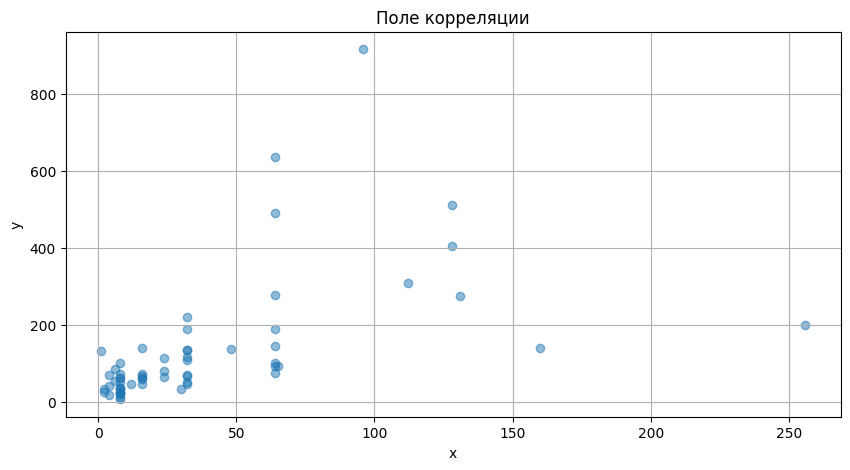

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

df = pd.read_csv('RGR3_A_2.csv')
x = df['x'].values
y = df['y'].values

plt.figure(figsize=(10, 5))
plt.scatter(x, y, alpha=0.5, label='Наблюдения')
plt.title('Поле корреляции')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

### 2. Построение и сравнение моделей
Рассмотрим 3 типа регрессионных моделей, оценим их параметры и качество ($R^2$ и среднюю ошибку аппроксимации $A$).

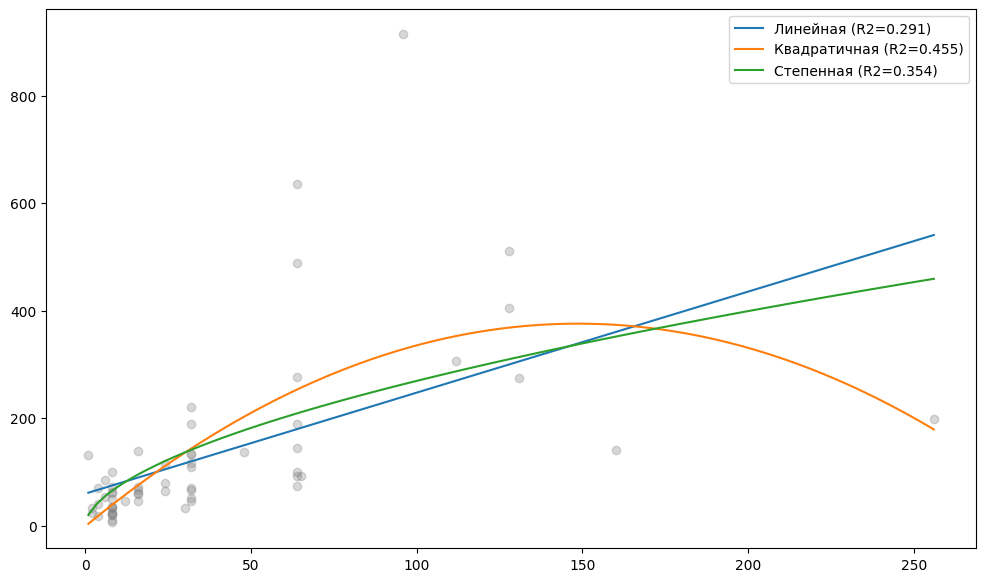

,Модель,R2,A (%)
1,Квадратичная,0.455027,75.224706
2,Степенная,0.353702,95.283374
0,Линейная,0.290697,104.119613


In [5]:
def linear_f(x, a, b): return a + b * x
def quad_f(x, a, b, c): return a + b * x + c * x**2
def power_f(x, a, b): return a * x**b

models = {
    'Линейная': linear_f,
    'Квадратичная': quad_f,
    'Степенная': power_f,
}

results = []
plt.figure(figsize=(12, 7))
plt.scatter(x, y, color='gray', alpha=0.3)

x_plot = np.linspace(min(x), max(x), 100)

for name, func in models.items():
    try:
        p0 = [1, 1, 1] if name == 'Квадратичная' else [1, 0.1]
        popt, _ = curve_fit(func, x, y, p0=p0)
        y_pred = func(x, *popt)
        r2 = r2_score(y, y_pred)
        a_err = np.mean(np.abs((y - y_pred) / y)) * 100
        
        results.append({'Модель': name, 'R2': r2, 'A (%)': a_err})
        plt.plot(x_plot, func(x_plot, *popt), label=f'{name} (R2={r2:.3f})')
    except: continue

plt.legend()
plt.show()

res_df = pd.DataFrame(results)
display(res_df.sort_values('R2', ascending=False))

### Анализ и описание результатов

1. **Линейная модель**: показывает общую тенденцию. Если коэффициент $b$ положителен, наблюдается прямой рост.
2. **Степенная модель**: интерпретируется через эластичность. Параметр степени показывает, на сколько процентов изменится $y$ при изменении $x$ на 1%.
3. **Квадратичная модель**: позволяет учесть нелинейность и наличие экстремумов.

**Вывод:**
Лучшей моделью по критерию максимума $R^2$ и минимума ошибки $A$ является **Квадратичная** модель ($R^2 = 0.455$).